# AML - Butterflies

This project aims to develop a 3 differente models of Neural Networks (MLP, CNN and ResNets), with different Loss functions

## Files Setup

In [1]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
try:
    path = Path('/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies')
   
    if not path.exists():
        raise FileNotFoundError(f"The specified path does not exist: {path}")

except FileNotFoundError:
    path = Path('/content/drive/MyDrive/AdvancedMachineLearning/aca-butterflies')

In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

import warnings
warnings.filterwarnings("ignore")

In [4]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [5]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

### Dataset manipulation class

In [6]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [7]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [8]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


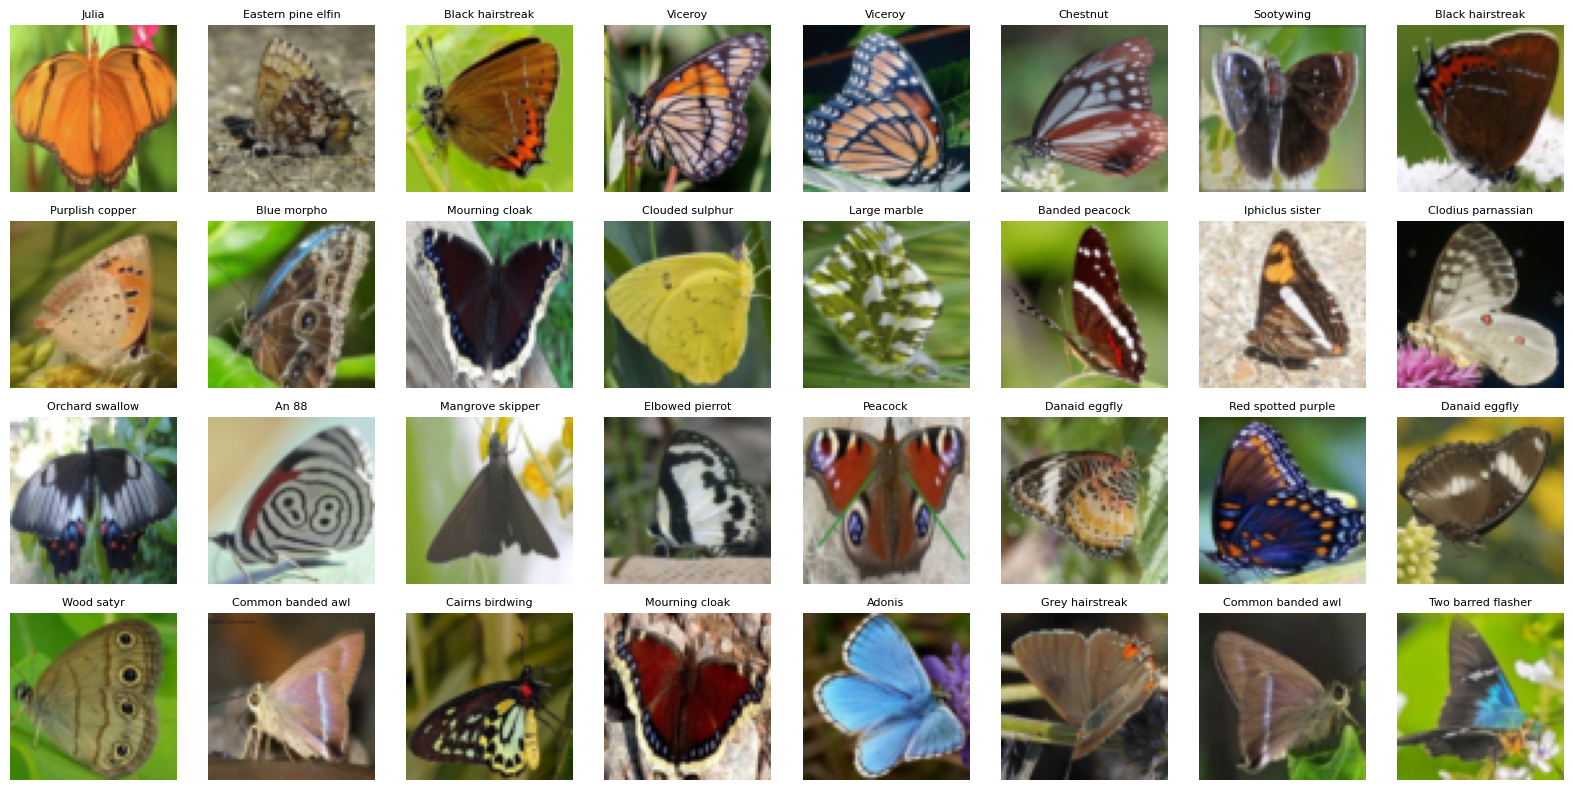

In [9]:
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    # permutation compute for Matplotlib (C, H, W) -> (H, W, C)
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Dataset analysis

### Class distribution

Class distribution:
label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64


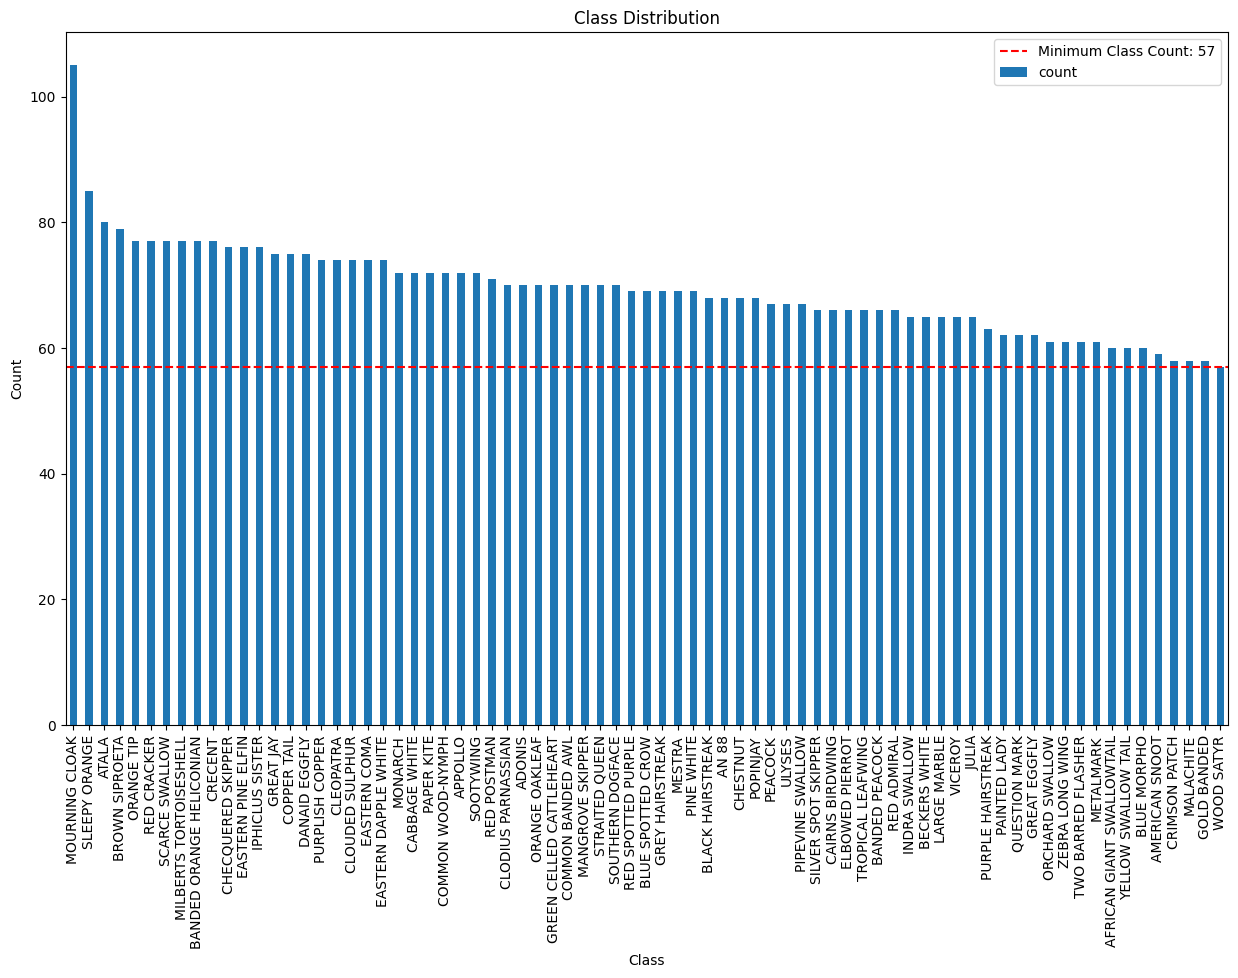

In [10]:
# Compute class distribution
import matplotlib.pyplot as plt

class_counts = df['label'].value_counts()
print("Class distribution:")
print(class_counts)

# Plot class distribution
plt.figure(figsize=(15, 9))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.axhline(y=class_counts.min(), color='red', linestyle='--', label=f'Minimum Class Count: {class_counts.min()}')
plt.xticks(rotation=90)
plt.legend()
plt.show()

At first analysis the dataset was deeply unbalanced, so we must to explore different techniques to deal with this issue

## Oversampling

Attention: to perform only 1 time!

In [11]:
import random

random.seed(42)

majority_class = class_counts.idxmax()
minority_classes = class_counts[class_counts < class_counts.max()].index

print(f"Majority class: {majority_class} with {class_counts.max()} samples")
print(f"Minority classes length: {len(minority_classes)}")


for minority_class in minority_classes:
    minority_count = class_counts[minority_class]
    majority_count = class_counts[majority_class]
    samples_to_add = majority_count - minority_count

    print(f"Class '{minority_class}' has {minority_count} samples. Adding {samples_to_add} samples to match the majority class.")

    # Get all images of the minority class
    minority_images = df[df['label'] == minority_class]['filename'].tolist()

    # Randomly sample images from the minority class to create new samples
    for _ in range(samples_to_add):
        img_name = random.choice(minority_images)
        img_path = os.path.join(img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        # Apply random transformations
        transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor()
        ])

        transformed_image = transform(image)

        # Save the transformed image with a new name
        new_img_name = f"{minority_class}_aug_{_}.jpg"
        new_img_path = os.path.join(img_dir, new_img_name)
        transformed_image_pil = transforms.ToPILImage()(transformed_image)
        transformed_image_pil.save(new_img_path)

        # Add the new sample to the dataframe
        new_row = pd.DataFrame([{'filename': new_img_name, 'label': minority_class}])
        df = pd.concat([df, new_row], ignore_index=True)

# Verify the new class distribution
new_class_counts = df['label'].value_counts()
print("New class distribution after oversampling:")
print(new_class_counts)

Majority class: MOURNING CLOAK with 105 samples
Minority classes length: 74
Class 'SLEEPY ORANGE' has 85 samples. Adding 20 samples to match the majority class.
Class 'ATALA' has 80 samples. Adding 25 samples to match the majority class.
Class 'BROWN SIPROETA' has 79 samples. Adding 26 samples to match the majority class.
Class 'ORANGE TIP' has 77 samples. Adding 28 samples to match the majority class.
Class 'RED CRACKER' has 77 samples. Adding 28 samples to match the majority class.
Class 'SCARCE SWALLOW' has 77 samples. Adding 28 samples to match the majority class.
Class 'MILBERTS TORTOISESHELL' has 77 samples. Adding 28 samples to match the majority class.
Class 'BANDED ORANGE HELICONIAN' has 77 samples. Adding 28 samples to match the majority class.
Class 'CRECENT' has 77 samples. Adding 28 samples to match the majority class.
Class 'CHECQUERED SKIPPER' has 76 samples. Adding 29 samples to match the majority class.
Class 'EASTERN PINE ELFIN' has 76 samples. Adding 29 samples to ma

In [11]:
print("New shape of the dataset after oversampling:", df.shape)

plt.figure(figsize=(15, 9))
new_class_counts.plot(kind='bar')
plt.title('New Class Distribution After Oversampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.axhline(y=class_counts.max(), color='green', linestyle='--', label=f'Majority Class Count: {class_counts.max()}')
plt.xticks(rotation=90)
plt.legend()
plt.show()


New shape of the dataset after oversampling: (5199, 2)


NameError: name 'new_class_counts' is not defined

<Figure size 1500x900 with 0 Axes>

In [13]:
df.head()
df.to_csv(os.path.join(path, 'train_oversampled.csv'), index=False)

## Class Weighting

### Compute the class weights for each class

In [12]:
df_original = pd.read_csv(os.path.join(path, 'train.csv'))

# Compute class distribution for the original dataset
class_counts = df_original['label'].value_counts()
print("Class distribution:")
print(class_counts)

# Compute the weight for each class
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
print("\nClass weights:")
print(class_weights)

# Convert to tensors
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)
print("\nClass weights tensor:")
print(class_weights_tensor)

loss = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

dataset = ButterflyDataset(df=df_original, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Class distribution:
label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64

Class weights:
label
MOURNING CLOAK    0.653473
SLEEPY ORANGE     0.807232
ATALA             0.857684
BROWN SIPROETA    0.868540
ORANGE TIP        0.891100
                    ...   
AMERICAN SNOOT    1.162961
CRIMSON PATCH     1.183012
MALACHITE         1.183012
GOLD BANDED       1.183012
WOOD SATYR        1.203767
Name: count, Length: 75, dtype: float64

Class weights tensor:
tensor([0.6535, 0.8072, 0.8577, 0.8685, 0.8911, 0.8911, 0.8911, 0.8911, 0.8911,
        0.8911, 0.9028, 0.9028, 0.9028, 0.9149, 0.9149, 0.9149, 0.9272, 0.9272,
        0.9272, 0.9272, 0.9272, 0.9530, 0.9530, 0.9530, 0.9530, 0.9530, 0.9530,
        0.9664, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 

### WeightedRandomSampler

In [13]:
from torch.utils.data import WeightedRandomSampler

df_original = pd.read_csv(os.path.join(path, 'train.csv'))

# 1. Contiamo quante immagini ci sono per ogni specie
class_counts = df_original['label'].value_counts()
print("Class counts:", class_counts)

# 2. Calcoliamo i pesi (più la classe è rara, più alto è il peso)
weights = (1.0 / class_counts).to_dict()
print("Class weights:", weights)


# 3. Mappiamo ogni riga del DataFrame al suo peso corrispondente
# Questo trasforma i nomi in numeri (pesi) automaticamente
sample_weights = df_original['label'].map(weights).tolist()

# 3. Creiamo il sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# 4. Creiamo il DataLoader (fondamentale: shuffle deve essere False se usi il sampler)
train_loader = data.DataLoader(dataset, batch_size=32, sampler=sampler)

print("Sampler configurato e pronto!")

print("✅ Sampler creato con successo!")
print(f"Esempio primi 3 pesi nella lista: {sample_weights[:3]}")

Class counts: label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64
Class weights: {'MOURNING CLOAK': 0.009523809523809525, 'SLEEPY ORANGE': 0.011764705882352941, 'ATALA': 0.0125, 'BROWN SIPROETA': 0.012658227848101266, 'ORANGE TIP': 0.012987012987012988, 'RED CRACKER': 0.012987012987012988, 'SCARCE SWALLOW': 0.012987012987012988, 'MILBERTS TORTOISESHELL': 0.012987012987012988, 'BANDED ORANGE HELICONIAN': 0.012987012987012988, 'CRECENT': 0.012987012987012988, 'CHECQUERED SKIPPER': 0.013157894736842105, 'EASTERN PINE ELFIN': 0.013157894736842105, 'IPHICLUS SISTER': 0.013157894736842105, 'GREAT JAY': 0.013333333333333334, 'COPPER TAIL': 0.013333333333333334, 'DANAID EGGFLY': 0.013333333333333334, 'PURPLISH COPPER': 0.013513513513513514, 'CLEOPATRA': 0.01351351

In [14]:
# Verify the sampler by checking the distribution of classes in a few batches
images, labels = next(iter(train_loader))

# 2. count the lables in the batch
unique, counts = torch.unique(labels, return_counts=True)

print("--- CHECK BATCH ---")
print(f"Batch dimension: {labels.size(0)} immagini")
print(f"Different classes in this batch: {len(unique)}")
print("\nBatch distribution (Class: Count):")
for u, c in zip(unique, counts):
    print(f"Specie {u.item()}: present {c.item()} times")

# 3. Verifica visiva
if len(unique) > 10:
    print("\n✅ IL SAMPLER FUNZIONA: Il batch contiene molte classi diverse.")
else:
    print("\n⚠️ ATTENZIONE: Se vedi sempre la stessa classe, c'è un problema.")

--- CHECK BATCH ---
Batch dimension: 32 immagini
Different classes in this batch: 28

Batch distribution (Class: Count):
Specie 1: present 1 times
Specie 7: present 1 times
Specie 8: present 1 times
Specie 9: present 1 times
Specie 17: present 1 times
Specie 18: present 1 times
Specie 21: present 1 times
Specie 25: present 1 times
Specie 26: present 1 times
Specie 27: present 1 times
Specie 31: present 1 times
Specie 32: present 1 times
Specie 36: present 1 times
Specie 37: present 1 times
Specie 41: present 1 times
Specie 46: present 2 times
Specie 50: present 1 times
Specie 52: present 1 times
Specie 54: present 1 times
Specie 59: present 1 times
Specie 63: present 2 times
Specie 64: present 2 times
Specie 65: present 1 times
Specie 69: present 1 times
Specie 70: present 1 times
Specie 71: present 1 times
Specie 72: present 2 times
Specie 73: present 1 times

✅ IL SAMPLER FUNZIONA: Il batch contiene molte classi diverse.


### MLP implementation

In [22]:
# Implement the MLP
import torch.nn as nn 
import torch.nn.functional as F

class ButterflyMLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(ButterflyMLP, self).__init__()

        self.flatten = nn.Flatten()
        self.layers = nn.ModuleList()
        self.activations = nn.ModuleList()

        # Without hidden layers, just a single linear layer
        if len(hidden_size) == 0:
            self.layers.append(nn.Linear(input_size, num_classes))
        else:
            
            # First layer in the network
            self.layers.append(nn.Linear(input_size, hidden_size[0]))
            self.activations.append(nn.ReLU())

            for i in range(len(hidden_size) - 1):
                self.layers.append(nn.Linear(hidden_size[i], hidden_size[i+1]))
                self.activations.append(nn.ReLU())
            
            # Output layer
            self.layers.append(nn.Linear(hidden_size[-1], num_classes))

    def forward(self, x):
        # x ha forma [batch, 3, 64, 64]
        x = self.flatten(x) # diventa [batch, 12288]

        for i in range(len(self.activations)):
            x = self.layers[i](x)
            x = self.activations[i](x)
        
        # Passiamo l'ultimo layer (quello di output) SENZA attivazione
        x = self.layers[-1](x)
            
        return x

In [23]:
input_size = 3 * IMAGE_SIZE * IMAGE_SIZE
hidden_size = [512, 256]
num_classes = len(dataset.classes)
model = ButterflyMLP(input_size, hidden_size, num_classes).to(device)

# Test rapido
test_input = torch.randn(32, 3, 64, 64).to(device)
output = model(test_input)
print("Output shape:", output.shape) # Deve essere [32, 75]

Output shape: torch.Size([32, 75])


In [24]:
import torch.optim as optim

# CrossEntropyLoss è perfetta per classificazione a 75 classi
criterion = nn.CrossEntropyLoss()

# Adam è l'ottimizzatore standard più robusto
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
def train_model(model, train_loader, criterion, optimizer, device, num_epochs=10):
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            # Calcolo dell'accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = 100. * correct / total

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')

In [ ]:
# Training parameters
num_epochs = 10
print(f"Inizio allenamento su {device}...")

# Lists for saving results and plotting later
history = {'loss': [], 'acc': []}

for epoch in range(num_epochs):
    # CHIAMATA ALLA FUNZIONE train_model che abbiamo scritto prima
    loss, acc = train_model(model, train_loader, criterion, optimizer, device)
    
    # Salviamo i risultati
    history['loss'].append(loss)
    history['acc'].append(acc)
    
    # Stampiamo i progressi
    print(f"Epoch [{epoch+1}/{num_epochs}] -> Loss: {loss:.4f} | Accuracy: {acc:.2f}%")

print("--- Training Finito! ---")

Inizio allenamento su cuda...


KeyboardInterrupt: 

## Modeling Preparation

### Train / test split

In [15]:
from sklearn.model_selection import train_test_split


df_standard = pd.read_csv(os.path.join(path, 'train.csv'))
df_oversampled = pd.read_csv(os.path.join(path, 'train_oversampled.csv'))


def split_and_vectorize_images(
    df,
    img_dir,
    test_size=0.2,
    random_state=42,
    image_size=IMAGE_SIZE,
    batch_size=128,
    num_workers=None,
    verbose=True
):
    """
    Split the dataframe into train/test and convert images to flattened tensors.
    Optimized with batched loading via DataLoader.
    """
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=df['label']
    )

    classes = sorted(df['label'].unique())
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
    ])

    if num_workers is None:
        num_workers = 0 if os.name == 'nt' else min(4, os.cpu_count() or 1)

    class _SplitDataset(data.Dataset):
        def __init__(self, split_df):
            self.rows = split_df.reset_index(drop=True)

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, idx):
            row = self.rows.iloc[idx]
            img_path = os.path.join(img_dir, row['filename'])
            image = Image.open(img_path).convert('RGB')
            image = transform(image)
            label = class_to_idx[row['label']]
            return image, label

    def dataset_to_tensors(split_df, split_name='split'):
        loader = data.DataLoader(
            _SplitDataset(split_df),
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=torch.cuda.is_available()
        )

        x_batches = []
        y_batches = []

        for batch_idx, (images, labels) in enumerate(loader, start=1):
            # (N, C, H, W) -> (N, C*H*W)
            x_batches.append(images.view(images.size(0), -1).float())
            y_batches.append(labels.long())

            if verbose and (batch_idx % 20 == 0 or batch_idx == len(loader)):
                print(f"{split_name}: {batch_idx}/{len(loader)} batches processados")

        X = torch.cat(x_batches, dim=0)
        y = torch.cat(y_batches, dim=0)
        return X, y

    X_train, y_train = dataset_to_tensors(train_df, split_name='train')
    X_test, y_test = dataset_to_tensors(test_df, split_name='test')

    return X_train, X_test, y_train, y_test, class_to_idx


X_train, X_test, y_train, y_test, class_to_idx = split_and_vectorize_images(
    df=df_standard,
    img_dir=os.path.join(path, 'train')
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
print('Number of classes:', len(class_to_idx))

train: 20/33 batches processados
train: 33/33 batches processados


KeyboardInterrupt: 

### Training function

In [ ]:
def fit(X_train, y_train, nn, criterion, optimizer, n_epochs, to_device=True, batch_size=32):
    # send everything to the device (ideally a GPU)
    if to_device:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        nn = nn.to(device)
        X_train = X_train.to(device)
        y_train = y_train.to(device)

    # Train the network
    loss_values = []
    for epoch in range(n_epochs):
        accu_loss = 0.0
        for i in range(0, X_train.size(0), batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            # Forward pass
            outputs = nn(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            accu_loss += loss.item() * X_batch.size(0)

        accu_loss /= X_train.size(0)
        print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch + 1, n_epochs, accu_loss))
        loss_values.append(accu_loss)

    return loss_values, nn.to("cpu")

## Multi-Layer Perceptron

In [ ]:
import torch.nn as nn
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x